In [1]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from transformers_sae import _autoreload

# from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 1
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )
    model.eval()
    model.requires_grad_(False)

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

/cloud-dev/.venv/lib/python3.13/site-packages/codefind/registry.py:46: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, types.FunctionType):


Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

GemmaReplacementInstance(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [2]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(5e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
D_SAE = 16384
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

# Train SAEs for comparison


In [3]:
import numpy as np

from transformers_sae.sae import SAE, make_sae_config
from transformers_sae.training import TrainingConfig, TrainingMethod, train
from transformers_sae.validation import run_validations


def SAE_SPECS():
    return TrainingMethod.__iter__()


N_ITERATIONS = 5
empty_saes = {
    method: {
        layer: SAE(
            make_sae_config(
                d_model=model.d_model,
                d_sae=D_SAE,
                device=TRAINING_DEVICE,
                train_dtype=torch.float32,
                inference_dtype=torch.bfloat16,
                activation_kind="batch_topk",
                top_k=list(range(TOPK // N_ITERATIONS, TOPK + 1, TOPK // N_ITERATIONS)),
                encoder_kind="lista",
                n_iterations=N_ITERATIONS,
            )
        )
        for layer in range(model.num_layers)
    }
    for method in SAE_SPECS()
}


def linear_decay_during_finetune(frac_trained: float, **kwargs):
    if frac_trained < (1 - FINETUNE_FRACTION):
        return 1.0
    return 1.0 - (frac_trained - (1 - FINETUNE_FRACTION)) / FINETUNE_FRACTION


training_config = {
    method: TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.num_layers)),
        lr=1e-4,
        interaction_lr=1e-4,
        threshold_lr=1e-2,
        lr_schedule=linear_decay_during_finetune,  # per Karvonen (2025)
        downstream_reconstruction_weight=1.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=True,
        method=method,
        finetune_fraction=FINETUNE_FRACTION
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method in SAE_SPECS()
}

training_results = {}
validation_results = {}

## Train with each method

`TrainingMethod.standard` is the standard TopK training method (reconstruction error only)

`TrainingMethod.next_layer` is my replacement-aware training method as described in [the blog post](https://elloworld.net/posts/replacement-aware-sae-training/), in which a term for the feature-space error of the next layer's SAE is added to the standard SAE loss function.

`TrainingMethod.e2e` is a recreation of the method SAE_e2e+ds from

> Braun, Dan, Jordan Taylor, Nicholas Goldowsky-Dill, and Lee Sharkey. 2024. “Identifying Functionally Important Features with End-to-End Sparse Dictionary Learning.” arXiv [Cs.LG]. arXiv. http://arxiv.org/abs/2405.12241.



In [4]:
[a.config.k for a in empty_saes[TrainingMethod.standard][0].encoder.activation]

[20, 40, 60, 80, 100]

In [5]:
from transformers_sae.ops import (
    find_latest_checkpoint,
    load_checkpoint,
)
from concurrent.futures import ThreadPoolExecutor
import os

START_LAYER = 20

def load_saes(checkpoint_dir: str, start_layer: int = 0):
    saes = {}

    def load_layer_checkpoint(layer):
        checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
        if checkpoint is not None:
            cp = load_checkpoint(checkpoint)
            if cp.total_tokens_trained < NUM_TRAINING_TOKENS:
                print(f"No checkpoint found for layer {layer}")
                return layer, None
            sae = cp.sae
            print(f"Loaded checkpoint for layer {layer}")
            return layer, sae
        else:
            print(f"No checkpoint found for layer {layer}")
            return layer, None

    # Load the latest checkpoints for each layer in parallel
    with ThreadPoolExecutor() as executor:
        results = executor.map(
            load_layer_checkpoint, range(model.num_layers - 1, start_layer - 1, -1)
        )
        for layer, sae in results:
            if sae is not None:
                saes[layer] = sae

    return saes

saes = load_saes(f"{os.getenv('HF_BUCKET_LOCAL')}/gemma_2_2b/next_layer_lista", START_LAYER)

Loaded checkpoint for layer 25
Loaded checkpoint for layer 20
Loaded checkpoint for layer 24
Loaded checkpoint for layer 21
Loaded checkpoint for layer 22
Loaded checkpoint for layer 23


In [21]:
from transformers_sae.encoder import BatchTopKActivationFunction
for sae in saes.values():
    for a in sae.encoder.config.per_layer_activation_functions:
        a.softcap = True
    for a in sae.encoder.activation:
        a.cap = torch.full((D_SAE,), BatchTopKActivationFunction.INIT_CAP, device=TRAINING_DEVICE)


In [23]:
saes[25].encoder.activation[0].threshold

tensor(44.3806, dtype=torch.float64)

In [24]:
from transformers_sae.training import tune_activation_caps

tune_activation_caps(
    model,
    tokenizer,
    saes,
    training_dataset,
    TOKENIZER_BATCH_SIZE,
    TRAINING_BATCH_SIZE,
    int(1e6),
)

cap 25 (tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'))
cap 24 (tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'))
cap 23 (tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), tensor([1000., 1000., 1000.,  ..., 1000., 1000., 1000.], device='cuda:0'), t

Tuning BatchTopK thresholds for replacement model

  0%|          | 0/1000000 [00:00<?, ?it/s]

cap 25 (tensor([66.8552, 44.0567, 70.9950,  ..., 37.1236, 80.4650, 81.2940],
       device='cuda:0'), tensor([131.5627,  19.0679,  62.9897,  ...,  59.3794,  73.9508,  18.1088],
       device='cuda:0'), tensor([40.2120, 10.8630, 32.0552,  ..., 10.8694, 52.1034, 11.1245],
       device='cuda:0'), tensor([111.0252,  25.3925,  48.8412,  ...,  26.0171,  60.8646,  27.1547],
       device='cuda:0'), tensor([44.6179, 19.6792, 46.6853,  ..., 20.8156, 49.2659, 22.6585],
       device='cuda:0'))
cap 24 (tensor([44.2720, 21.3281, 56.7777,  ..., 23.4727, 63.6599, 40.5894],
       device='cuda:0'), tensor([88.2072, 76.4513, 27.2231,  ...,  9.7930, 42.6720,  8.8019],
       device='cuda:0'), tensor([29.3347, 11.4871, 37.4047,  ...,  9.0144, 40.7951,  8.4656],
       device='cuda:0'), tensor([ 645.9961, 1093.0762,   48.3042,  ...,   13.3825,  370.7789,
          13.5862], device='cuda:0'), tensor([32.6113, 17.6054, 44.7565,  ..., 14.7129, 40.9493, 14.9552],
       device='cuda:0'))
cap 23 (tensor([16.

In [25]:
from safetensors.torch import save_file as save_file_torch
import os

# Save the state dicts for each sae to HF_BUCKET_LOCAL/next_layer_lista_with_caps/{layer}.sd
output_dir = os.path.join(os.getenv("HF_BUCKET_LOCAL"), "next_layer_lista_with_caps")
os.makedirs(output_dir, exist_ok=True)
for layer, sae in saes.items():
    out_path = os.path.join(output_dir, f"{layer}.sd")
    save_file_torch(sae.state_dict(), out_path)
    print(f"Saved SAE state dict for layer {layer} to {out_path}")

Saved SAE state dict for layer 25 to /workspace/sae_checkpoints/next_layer_lista_with_caps/25.sd
Saved SAE state dict for layer 24 to /workspace/sae_checkpoints/next_layer_lista_with_caps/24.sd
Saved SAE state dict for layer 23 to /workspace/sae_checkpoints/next_layer_lista_with_caps/23.sd
Saved SAE state dict for layer 22 to /workspace/sae_checkpoints/next_layer_lista_with_caps/22.sd
Saved SAE state dict for layer 21 to /workspace/sae_checkpoints/next_layer_lista_with_caps/21.sd
Saved SAE state dict for layer 20 to /workspace/sae_checkpoints/next_layer_lista_with_caps/20.sd


In [26]:
# Load state dict with caps for layer 25
from safetensors.torch import load_file as load_file_torch

layer_to_load = 25
sae_loaded = saes[layer_to_load]
state_dict_path = os.path.join(
    os.getenv("HF_BUCKET_LOCAL"), "next_layer_lista_with_caps", f"{layer_to_load}.sd"
)
state_dict = load_file_torch(state_dict_path)
sae_loaded.load_state_dict(state_dict, strict=True)

In [27]:
sae_loaded.encoder.activation[3].threshold

tensor(16.7333, dtype=torch.float64)

In [28]:
sae_loaded.encoder.activation[3].cap

tensor([111.0252,  25.3925,  48.8412,  ...,  26.0171,  60.8646,  27.1547],
       device='cuda:0')

In [6]:
from transformers_sae.training import tune_activation_thresholds

for start_layer in (START_LAYER,):
    tune_activation_thresholds(
        model,
        tokenizer,
        {layer: sae for layer, sae in saes.items() if layer >= start_layer},
        training_dataset,
        TOKENIZER_BATCH_SIZE,
        TRAINING_BATCH_SIZE,
        int(1e6),
        offload_after_training=False,
    )
    validations = run_validations(
        model,
        tokenizer,
        saes,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        TRAINING_BATCH_SIZE,
        NUM_VALIDATION_TOKENS,
        start_layer=start_layer,
        offload=False,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validations.layer_results.items() if v.rre is not None} }"
    )
    print(
        f"geom mean rre={ {k: np.exp(np.mean(np.log(np.clip(v.rre, a_min=1e-9, a_max=None)))).item() for k, v in validations.layer_results.items() if v.rre is not None} }"
    )

    print(
        f"mean l0={ {k: np.mean(v.l0).item() for k, v in validations.layer_results.items() if v.l0 is not None} }"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validations.layer_results.items() if v.kl is not None} }"
    )
    print(
        f"arith mean kl={ {k: np.mean(v.kl).item() for k, v in validations.layer_results.items() if v.kl is not None} }"
    )
    print(
        f"live features={ {k: sum(v.live_features) / saes[k].config.d_sae for k, v in validations.layer_results.items() if v.live_features is not None} }"
    )

scale 25 Parameter containing:
tensor([0.5047, 0.2857, 0.1898, 0.4955, 0.3389], device='cuda:0',
       requires_grad=True)
thresh 25 (44.38057226093359, 20.28294495652779, 7.877862433012863, 16.73325355132538, 10.83707074605779)
scale 24 Parameter containing:
tensor([0.4527, 0.2589, 0.2280, 0.3612, 0.2842], device='cuda:0',
       requires_grad=True)
thresh 24 (30.457222429136923, 7.518025998438199, 5.8682755949372005, 7.7165424302645915, 7.2121171888521936)
scale 23 Parameter containing:
tensor([0.2124, 0.1804, 0.6637, 0.1789, 0.2212], device='cuda:0',
       requires_grad=True)
thresh 23 (12.749955902971546, 2.8044140331107568, 5.8598048774143905, 4.571670613623197, 4.995579774446701)
scale 22 Parameter containing:
tensor([0.2386, 0.1361, 0.6125, 0.1507, 0.1802], device='cuda:0',
       requires_grad=True)
thresh 22 (11.52198258186918, 2.555446376736772, 5.170816727333205, 3.5156577678360477, 3.8214642393022724)
scale 21 Parameter containing:
tensor([0.1941, 0.1265, 0.5215, 0.1274, 

Tuning BatchTopK thresholds for replacement model

  0%|          | 0/1000000 [00:00<?, ?it/s]

scale 25 Parameter containing:
tensor([0.4792, 0.2565, 0.1557, 0.4661, 0.3069], device='cuda:0',
       requires_grad=True)
thresh 25 (40.7214728171846, 16.14882755848766, 3.7383193191850554, 8.100247528729058, 4.599191118093566)
scale 24 Parameter containing:
tensor([0.4269, 0.2331, 0.2008, 0.3348, 0.2570], device='cuda:0',
       requires_grad=True)
thresh 24 (26.644881651852387, 3.9784993382940277, 2.460987425609032, 2.5568378177025424, 2.486811982779787)
scale 23 Parameter containing:
tensor([0.2059, 0.1622, 0.6413, 0.1544, 0.1955], device='cuda:0',
       requires_grad=True)
thresh 23 (10.780872137257722, 0.909153986652444, 0.4377664809310648, 1.815136534844488, 1.5047542848182587)
scale 22 Parameter containing:
tensor([0.2462, 0.1235, 0.5907, 0.1310, 0.1663], device='cuda:0',
       requires_grad=True)
thresh 22 (10.157999670121757, 1.3748559948154135, 0.6846024918012846, 1.2736950037505521, 1.2273908210558497)
scale 21 Parameter containing:
tensor([0.2090, 0.1243, 0.5079, 0.1152

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={20: 0.38458409905433655, 21: 0.410261869430542, 22: 0.4576736092567444, 23: 0.5073978304862976, 24: 0.5453957319259644, 25: 0.6050703525543213}
geom mean rre={20: 0.3791438043117523, 21: 0.40151405334472656, 22: 0.43846261501312256, 23: 0.46721193194389343, 24: 0.4758330285549164, 25: 0.5364527106285095}
mean l0={20: 104.86263275146484, 21: 104.88258361816406, 22: 104.91243743896484, 23: 104.70924377441406, 24: 108.26665496826172, 25: 113.57489776611328}
geom mean kl={26: 0.20587743818759918}
arith mean kl={26: 0.8341744542121887}
live features={20: 0.99969482421875, 21: 0.99969482421875, 22: 0.99993896484375, 23: 1.0, 24: 1.0, 25: 1.0}


In [67]:
from transformers_sae.tokenization import make_dataloader
from transformers_sae.activation_data import make_activation_batch

for sae in saes.values():
    sae.onload()
    sae.eval()
STATS_LAYER = model.num_layers - 2

full_replacement_model = make_replacement_model(model, saes)
sae_replacement_model = make_replacement_model(
    model,
    {STATS_LAYER: saes[STATS_LAYER]},
)

baseline_features = torch.empty((0, saes[START_LAYER].config.d_sae), dtype=torch.float32, device="cpu")
replacement_features = torch.empty((0, saes[START_LAYER].config.d_sae), dtype=torch.float32, device="cpu")

with torch.no_grad():
    for batch in make_dataloader(
        model,
        tokenizer,
        validation_dataset,
        max_tokens=int(1e4),
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        inference_batch_size=TRAINING_BATCH_SIZE,
    ):
        batch.to(TRAINING_DEVICE)
        baseline_sae = make_activation_batch(
            sae_replacement_model,
            [(STATS_LAYER, "sae")],
            batch,
            end_layer=model.num_layers,
        )
        replacement_sae = make_activation_batch(
            full_replacement_model,
            [(STATS_LAYER, "sae")],
            batch,
            end_layer=model.num_layers,
        )
        baseline_features = torch.cat(
            (
                baseline_features,
                baseline_sae[STATS_LAYER]
                .sae_features[batch.token_mask.bool()]
                .view(batch.num_tokens - batch.special_token_indices.numel(), -1)
                .cpu(),
            )
        )
        replacement_features = torch.cat(
            (
                replacement_features,
                replacement_sae[STATS_LAYER]
                .sae_features[batch.token_mask.bool()]
                .view(batch.num_tokens - batch.special_token_indices.numel(), -1)
                .cpu(),
            )
        )


In [68]:
baseline_features.shape

torch.Size([10124, 16384])

In [69]:
(baseline_features > 0).sum() / baseline_features.shape[0]

tensor(98.6066)

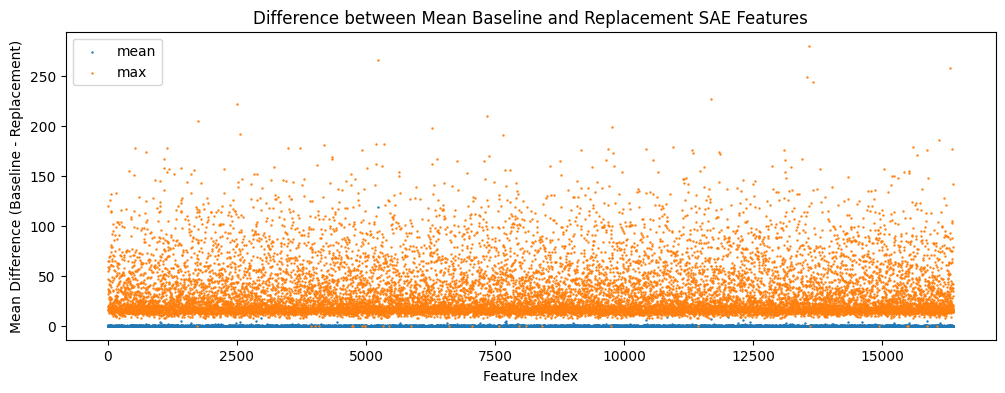

In [70]:
import matplotlib.pyplot as plt

# Compute means
baseline_mean = baseline_features.mean(dim=0)
replacement_mean = replacement_features.mean(dim=0)
baseline_max = baseline_features.max(dim=0).values

# Compute difference
# mean_diff = (baseline_mean - replacement_mean).abs()
mean_diff = baseline_mean
max_diff = baseline_max

# Visualize
plt.figure(figsize=(12, 4))
# plt.plot(mean_diff.numpy(), label="mean")
plt.scatter(np.arange(mean_diff.shape[0]), mean_diff.numpy(), label="mean", marker=".", s=2)
plt.scatter(np.arange(max_diff.shape[0]), max_diff.numpy(), label="max", marker=".", s=2)
plt.title("Difference between Mean Baseline and Replacement SAE Features")
plt.xlabel("Feature Index")
plt.ylabel("Mean Difference (Baseline - Replacement)")
plt.legend()

# plt.yscale("log")
plt.show()

In [71]:
baseline_features.max(dim=0).values.max(dim=0)

torch.return_types.max(
values=tensor(280.),
indices=tensor(13586))

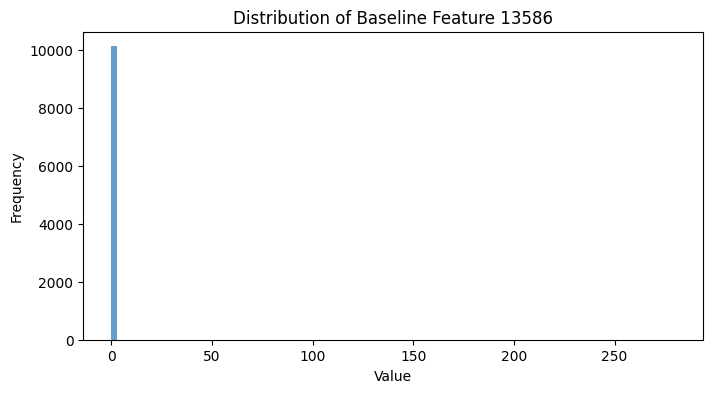

In [73]:
import matplotlib.pyplot as plt

feature_idx = 13586

# Plot distribution of values for baseline feature 5239
plt.figure(figsize=(8,4))
plt.hist(baseline_features[:, feature_idx].numpy(), bins=100, alpha=0.7)
plt.title(f"Distribution of Baseline Feature {feature_idx}")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

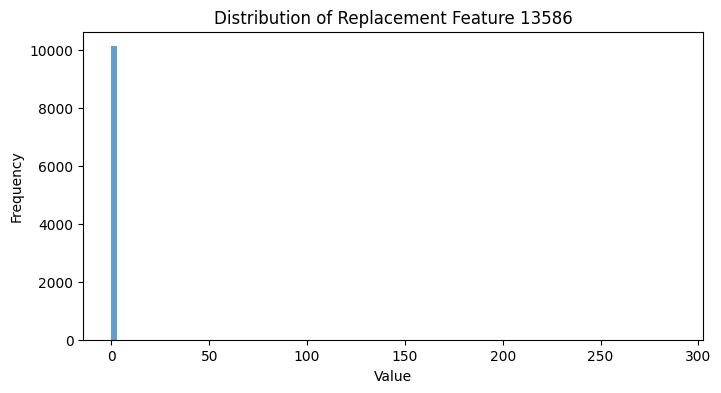

In [74]:
import matplotlib.pyplot as plt

feature_idx = 13586

# Plot distribution of values for replacement feature 5239
plt.figure(figsize=(8,4))
plt.hist(replacement_features[:, feature_idx].numpy(), bins=100, alpha=0.7)
plt.title(f"Distribution of Replacement Feature {feature_idx}")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from collections import defaultdict
from contextlib import nullcontext
from transformers_sae.training import tune_activation_thresholds

FOR_LAYER = 12

for spec in (
    TrainingMethod.standard,
    # TrainingMethod.next_layer,
    # TrainingMethod.e2e,
    # TrainingMethod.next_layer_finetuned,
    # TrainingMethod.full_replacement,
):
    print(f"Training {spec.value}")
    training_config[spec].num_train_tokens = int(1e6)
    training_config[spec].train_layers = [FOR_LAYER]
    # training_config[spec].train_layers = [0, 1, 2, 3]
    # with MemoryTrackingMode() as mm:
    with nullcontext():
        training_results[spec] = train(
            model,
            tokenizer,
            {FOR_LAYER: empty_saes[spec][FOR_LAYER]},
            # empty_saes[spec],
            training_dataset,
            training_config[spec],
            offload_after_training=False,
            skip_kl_eval=True,
        )
    # print(mm.memory_max)
    # tune_activation_thresholds(
    #     model,
    #     tokenizer,
    #     training_results[spec].final_saes,
    #     training_dataset,
    #     training_config[spec].tokenizer_batch_size,
    #     training_config[spec].training_batch_size,
    #     int(1e6),
    #     offload_after_training=False,
    # )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        start_layer=FOR_LAYER,
        end_layer=FOR_LAYER+1,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} }"
    )
    print(
        f"mean l0={ {k: np.mean(v.l0).item() for k, v in validation_results[spec].layer_results.items() if v.l0 is not None} }"
    )
    # print(
    #     f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} }"
    # )
    print(
        f"live features={ {k: sum(v.live_features) / empty_saes[spec][0].config.d_sae for k, v in validation_results[spec].layer_results.items() if v.live_features is not None} }"
    )

Training Standard


Layer 10

  0%|          | 0/1000000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={10: 0.5137687921524048}
mean l0={10: 102.07112884521484}
live features={10: 0.9684244791666666}


In [51]:
# Sum the number of parameters in the final_saes[0].encoder
num_params = sum(p.numel() for p in training_results[spec].final_saes[0].encoder.parameters())
print(f"Total parameters in final_saes[0].encoder: {num_params}")

Total parameters in final_saes[0].encoder: 106186752


In [17]:
empty_saes[spec][0].encoder.layers

ModuleList(
  (0): Linear(in_features=2304, out_features=9216, bias=True)
  (1): Linear(in_features=9216, out_features=2304, bias=True)
  (2): Linear(in_features=2304, out_features=9216, bias=True)
  (3): Linear(in_features=9216, out_features=2304, bias=True)
)

In [33]:
training_results[spec].final_saes[0].encoder.activation[0].threshold

tensor(2.3073, dtype=torch.float64)

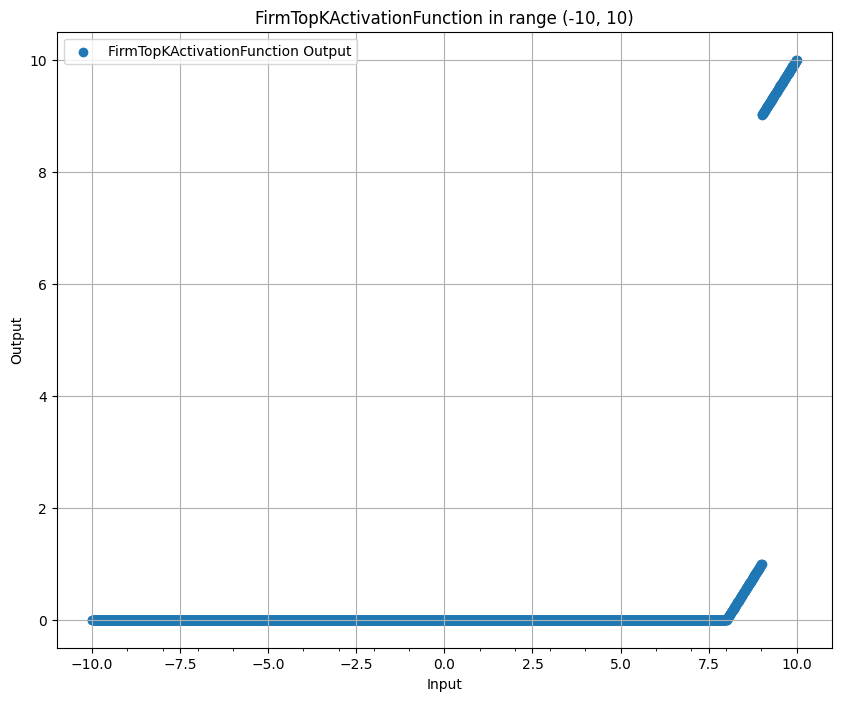

In [15]:
from transformers_sae.encoder import (
    FirmTopKActivationFunction,
    FirmTopKActivationFunctionConfig,
)

af = FirmTopKActivationFunction(
    FirmTopKActivationFunctionConfig(200, 100), torch.device(TRAINING_DEVICE)
)
# af.eval()
af.threshold[:] = torch.tensor([1, 5], device=torch.device(TRAINING_DEVICE))
import matplotlib.pyplot as plt
import numpy as np
import torch

x = torch.linspace(-10, 10, 2000, device=torch.device(TRAINING_DEVICE))
x = x.view(1, 1, -1)
# x = torch.randn((1, 1, 768), device=torch.device(TRAINING_DEVICE)) * 10

with torch.no_grad():
    y = af(x, token_mask=torch.ones_like(x, dtype=torch.bool)).view(-1).cpu().numpy()

plt.figure(figsize=(10, 8))
plt.scatter(x.view(-1).cpu().numpy(), y, label="FirmTopKActivationFunction Output")
plt.title("FirmTopKActivationFunction in range (-10, 10)")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()

xticks = np.arange(-10, 10.1, 1)
plt.xticks(xticks, minor=True)

plt.show()

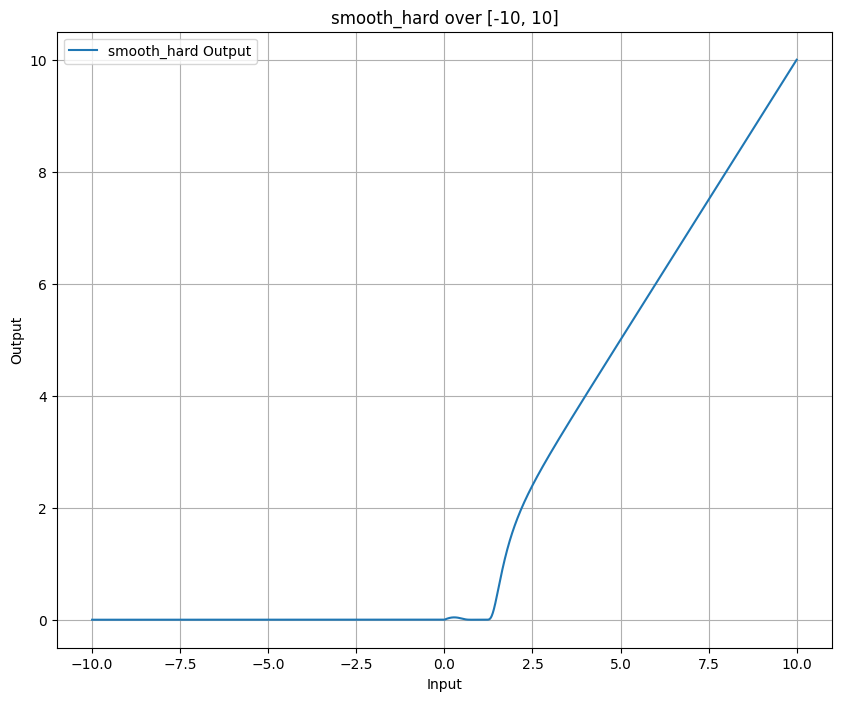

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from transformers_sae.encoder import smooth_hard

# Define range
x = torch.linspace(-10, 10, 2000)
x = x.view(1, 1, -1)  # Same shape as in the encoder code

# Use scalars for alpha and lambda, try some reasonable values
alpha = torch.tensor(0.5)
lamda = torch.tensor(1.0)

with torch.no_grad():
    y = smooth_hard(x, alpha, lamda).view(-1).cpu().numpy()

plt.figure(figsize=(10, 8))
plt.plot(x.view(-1).cpu().numpy(), y, label="smooth_hard Output")
plt.title("smooth_hard over [-10, 10]")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()


## Fine-tuning

`TrainingMethod.finetuned` is a recreation of the KL fine-tuning method from

> Karvonen, Adam. 2025. “Revisiting End-to-End Sparse Autoencoder Training: A Short Finetune Is All You Need.” arXiv [Cs.LG]. arXiv. http://arxiv.org/abs/2503.17272.

`TrainingMethod.next_layer_finetuned` is a modification of the above to also account for the next layer SAE's feature-space reconstruction error

In [ ]:
for spec in (
    # TrainingMethod.finetuned,
    TrainingMethod.next_layer_finetuned,
):
    print(f"Training {spec.value}")
    training_results[spec] = train(
        model,
        tokenizer,
        empty_saes[spec],
        training_dataset,
        training_config[spec],
        cache_dir=TRAINING_CACHE_DIR,
        checkpoint_dir=f".checkpoints/{spec.name}/",
        fine_tune_source_dir=".checkpoints/next_layer/"
        if spec is TrainingMethod.next_layer_finetuned
        else ".checkpoints/standard/",
        force_retrain=True,
    )
    validation_results[spec] = run_validations(
        model,
        tokenizer,
        training_results[spec].final_saes,
        validation_dataset,
        num_tokens=NUM_VALIDATION_TOKENS,
        tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
        inference_batch_size=training_config[spec].training_batch_size,
        cache_dir=VALIDATION_CACHE_DIR,
    )
    print(
        f"mean rre={ {k: np.mean(v.rre).item() for k, v in validation_results[spec].layer_results.items() if v.rre is not None} }"
    )
    print(
        f"geom mean kl={ {k: np.exp(np.mean(np.log(np.clip(v.kl, min=1e-9)))).item() for k, v in validation_results[spec].layer_results.items() if v.kl is not None} }"
    )
    print(
        f"live features={ {k: sum(v.live_features) / D_SAE for k, v in validation_results[spec].layer_results.items() if v.live_features is not None} }"
    )

Training Next Layer + Fine-Tuning


Layer 3

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 2

  0%|          | 0/994735 [00:00<?, ?it/s]

...

  0%|          | 0/994735 [00:00<?, ?it/s]

Layer 0

  0%|          | 0/994735 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

mean rre={0: 0.21447007358074188, 1: 0.2970157563686371, 2: 0.40990135073661804, 3: 0.6590347290039062})
geom mean kl={4: 0.10359175503253937})
live features={0: 0.9143880208333334, 1: 0.9140625, 2: 0.9189453125, 3: 0.9752604166666666}


# Evaluations and comparisons


## Train-time evaluations

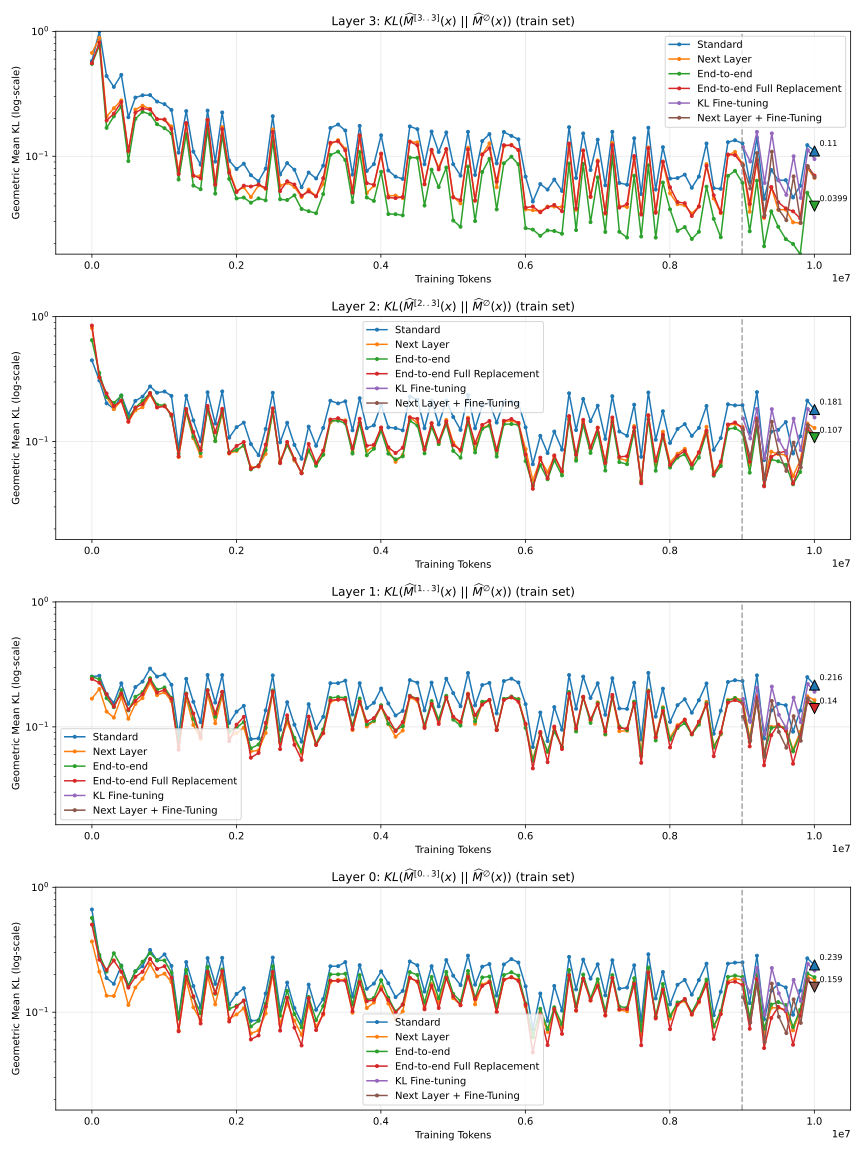

In [ ]:
import matplotlib.pyplot as plt

from transformers_sae.ops import current_plot_to_svg

fig, axes = plt.subplots(
    model.config.num_layers, 1, figsize=(12, 4 * model.config.num_layers)
)

# Collect all KL values to determine consistent y-axis limits
all_kl_values = []
for layer in range(model.config.num_layers):
    for method in training_results:
        # Iterate through all checkpoints for this layer
        for checkpoint in training_results[method][layer]:
            if "kl" in checkpoint.step_metrics:
                all_kl_values.extend(checkpoint.step_metrics["kl"])

# Calculate y-axis limits
if all_kl_values:
    y_min, y_max = min(all_kl_values), max(all_kl_values)
else:
    y_min, y_max = 1e-3, 1e0  # Default range if no data

for i, layer in enumerate(range(model.config.num_layers - 1, -1, -1)):
    ax = axes[i]

    # Collect final values for each method to find min/max
    final_values = {}
    line_colors = {}
    for method in training_results:
        # Concatenate metrics from all checkpoints for this layer
        all_tokens = []
        all_kl = []
        for checkpoint in training_results[method][layer]:
            if "kl" in checkpoint.step_metrics:
                all_tokens.extend(checkpoint.step_tokens_trained.tolist())
                all_kl.extend(checkpoint.step_metrics["kl"].tolist())
        
        if all_tokens and all_kl:
            # Skip plotting some steps to reduce clutter
            tokens = all_tokens
            kl_values = all_kl
            line = ax.plot(tokens, kl_values, label=method.value, marker="o", markersize=3)
            line_colors[method] = line[0].get_color()
            
            if tokens and kl_values:
                final_values[method] = (tokens[-1], kl_values[-1])

    # Find methods with highest and lowest final values
    if final_values:
        min_method = min(final_values.keys(), key=lambda m: final_values[m][1])
        max_method = max(final_values.keys(), key=lambda m: final_values[m][1])
        
        # Add indicators for min (down triangle) and max (up triangle)
        for method in [min_method, max_method]:
            final_token, final_kl = final_values[method]
            marker = '^' if method == max_method else 'v'
            ax.scatter(final_token, final_kl, s=100, marker=marker, 
                      color=line_colors[method], edgecolors='black', linewidth=1, zorder=10)
            ax.annotate(f'{final_kl:.3}', 
                       xy=(final_token, final_kl),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=8, ha='left')

    # Add vertical line at finetuning start
    ax.axvline(x=(1 - FINETUNE_FRACTION) * NUM_TRAINING_TOKENS, color='gray', linestyle='--', alpha=0.7)

    ax.set_xlabel("Training Tokens")
    ax.set_ylabel("Geometric Mean KL (log-scale)")
    ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"Layer {layer}: $KL(\\widehat{{M}}^{{[{layer}..3]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$ (train set)"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
current_plot_to_svg("train_rep_kl")

## Validation set evals

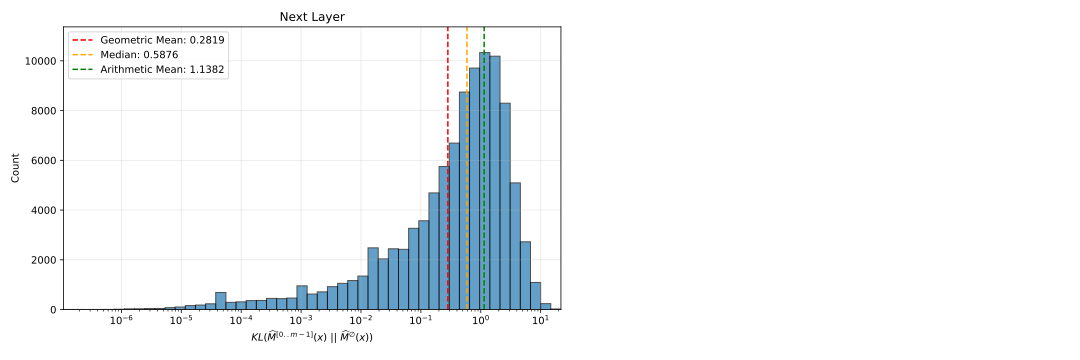

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

# Plot histograms of KL divergence for each method
num_methods = len(list(validation_results.keys()))
ncols = 2
nrows = (num_methods + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))

# Handle case where we have only one row
if nrows == 1:
    axes = axes.reshape(1, -1)
# Handle case where we have only one method
if num_methods == 1:
    axes = axes.reshape(-1)

# Calculate global min/max for consistent bins across all methods
all_kl_values = []
for method in validation_results.keys():
    kl_values = validation_results[method].layer_results[model.config.num_layers].kl
    all_kl_values.extend(kl_values[kl_values > 0])

global_min = np.min(all_kl_values)
global_max = np.max(all_kl_values)
log_bins = np.logspace(np.log10(global_min), np.log10(global_max), 50)

# Calculate global y-axis limits
max_frequency = 0
for method in validation_results.keys():
    kl_values = validation_results[method].layer_results[model.config.num_layers].kl
    counts, _ = np.histogram(kl_values, bins=log_bins)
    max_frequency = max(max_frequency, np.max(counts))

for i, method in enumerate(validation_results.keys()):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]
    
    kl_values = validation_results[method].layer_results[model.config.num_layers].kl

    # Create histogram with consistent bins
    ax.hist(kl_values, bins=log_bins, alpha=0.7, edgecolor="black")
    ax.set_xscale("log")
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(0, max_frequency * 1.1)
    ax.set_xlabel(r"$KL(\widehat{M}^{[0..m-1]}(x)\ ||\ \widehat{M}^{\emptyset}(x))$")
    ax.set_ylabel("Count")
    ax.set_title(method.value)
    ax.grid(True, alpha=0.3)

    # Compute log-normal distribution statistics
    log_kl_values = np.log(np.clip(kl_values, min=1e-9))
    log_mean = np.mean(log_kl_values)
    log_std = np.std(log_kl_values)
    
    # Geometric mean and geometric standard deviation for log-normal distribution
    geometric_mean = np.exp(log_mean)
    geometric_std = np.exp(log_std)
    
    # Median is the same as geometric mean for log-normal
    median_kl = np.median(kl_values)
    
    # Arithmetic mean
    mean_kl = np.mean(kl_values)
    
    ax.axvline(geometric_mean, color="red", linestyle="--", label=f"Geometric Mean: {geometric_mean:.4f}")
    ax.axvline(
        median_kl, color="orange", linestyle="--", label=f"Median: {median_kl:.4f}"
    )
    ax.axvline(
        mean_kl, color="green", linestyle="--", label=f"Arithmetic Mean: {mean_kl:.4f}"
    )
    
    ax.legend()

# Hide any unused subplots
for i in range(num_methods, nrows * ncols):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]
    ax.set_visible(False)

plt.tight_layout()
current_plot_to_svg("validation_kl_dist")

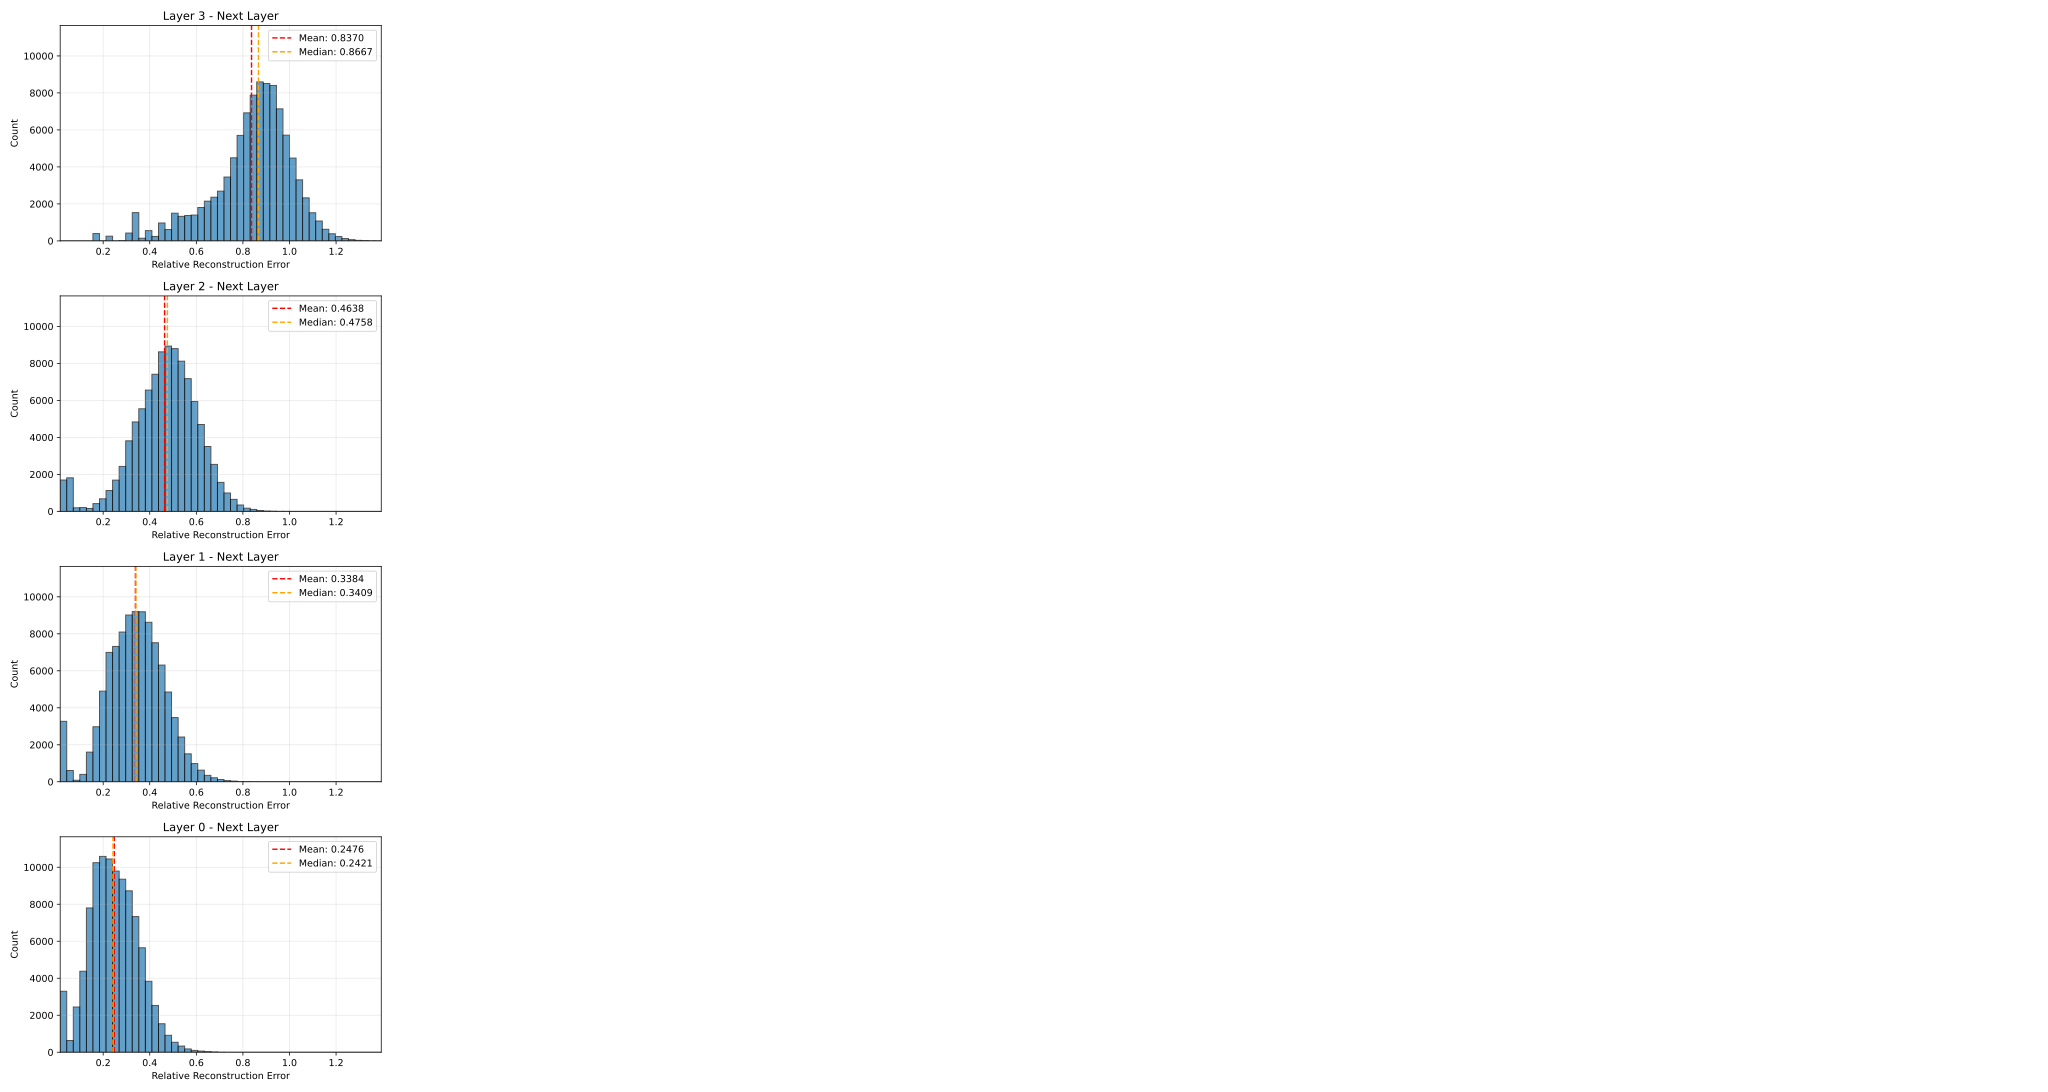

In [21]:
ncols = len(TrainingMethod)
nrows = model.num_layers

# Plot reconstruction error histograms
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

# Collect all rre values to determine global range
all_rre_values = []
for method in validation_results.keys():
    for layer in range(model.config.num_layers):
        rre_values = validation_results[method].layer_results[layer].rre
        if rre_values is not None:
            all_rre_values.extend(rre_values)

# Create consistent bins for all histograms
global_min = min(all_rre_values)
global_max = max(all_rre_values)
bins = np.linspace(global_min, global_max, 50)

# Find maximum frequency for consistent y-axis scaling
max_frequency = 0
for method in validation_results.keys():
    for layer in range(model.num_layers):
        rre_values = validation_results[method].layer_results[layer].rre
        if rre_values is not None:
            counts, _ = np.histogram(rre_values, bins=bins)
            max_frequency = max(max_frequency, max(counts))

# Plot histograms for each layer and method
for layer in range(model.num_layers):
    cur_col = 0
    for method in TrainingMethod:
        if method not in validation_results:
            continue
        # Reverse layer order: highest layer numbers on top
        plot_row = model.num_layers - 1 - layer
        row = plot_row
        ax = axes[row][cur_col]

        rre_values = validation_results[method].layer_results[layer].rre

        if rre_values is None:
            ax.set_visible(False)
            continue

        # Create histogram with consistent bins
        ax.hist(rre_values, bins=bins, alpha=0.7, edgecolor="black")
        ax.set_xlim(global_min, global_max)
        ax.set_ylim(0, max_frequency * 1.1)
        ax.set_xlabel("Relative Reconstruction Error")
        ax.set_ylabel("Count")
        ax.set_title(f"Layer {layer} - {method.value}")
        ax.grid(True, alpha=0.3)

        # Add statistics
        mean_rre = np.mean(rre_values)
        median_rre = np.median(rre_values)

        ax.axvline(mean_rre, color="red", linestyle="--", label=f"Mean: {mean_rre:.4f}")
        ax.axvline(
            median_rre,
            color="orange",
            linestyle="--",
            label=f"Median: {median_rre:.4f}",
        )

        ax.legend()
        cur_col += 1

# Hide any unused subplots
for i in range(cur_col, ncols):
    for row in axes:
        row[i].set_visible(False)

plt.tight_layout()
current_plot_to_svg("validation_rre")


In [11]:
from IPython.display import HTML

from transformers_sae.validation import generate_with_replacement

# Generate completions with and without SAE replacement
prompt = "Once upon a time"
sample_generations = {}

# Generate without replacement (baseline)
print("Generating baseline completion...")
baseline_tokens = generate_with_replacement(
    model,
    tokenizer,
    prompt,
    saes={},
    do_sample=False,
    stream=False,
    max_new_tokens=1000,
)
sample_generations["Baseline"] = tokenizer.decode(
    baseline_tokens[0], skip_special_tokens=True
)

# Generate with each SAE method
for spec, results in training_results.items():
    print(f"Generating completion with {spec.value}...")
    method_tokens = generate_with_replacement(
        model,
        tokenizer,
        prompt,
        saes=results.final_saes,
        do_sample=False,
        stream=False,
        max_new_tokens=1000,
    )
    sample_generations[spec.value] = tokenizer.decode(
        method_tokens[0], skip_special_tokens=True
    )

# Display results in HTML table
html_table = """
<table border="1" style="border-collapse: collapse; width: 100%;">
<tr style="background-color: #f2f2f2;">
<th style="padding: 10px; text-align: left;">Method</th>
<th style="padding: 10px; text-align: left;">Generated Text</th>
</tr>
"""

for method_name, text in sample_generations.items():
    html_table += f"""
<tr>
<td style="padding: 10px; vertical-align: top; font-weight: bold;">{method_name}</td>
<td style="padding: 10px; font-family: monospace; white-space: pre-wrap;">{text}</td>
</tr>
"""

html_table += "</table>"

display(HTML(html_table))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating baseline completion...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating completion with Next Layer...


Method,Generated Text
Baseline,"Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she saw a big, red apple on the ground. She picked it up and took a bite. It was so juicy and delicious! Suddenly, she heard a loud noise. It was a big, scary dog! Lily was scared and didn't know what to do. But then, she remembered the apple she had picked earlier. She took a bite and it was even more delicious than before! Lily learned that sometimes things that look scary can be delicious. She also learned that it's important to be brave and not give up. From that day on, Lily always carried an apple with her, just in case she needed to face her fears."
Next Layer,"Once upon a time, in a big forest, a little girl named Lily was walking in the forest. She saw a big, green tree with lots of leaves. She wanted to climb the tree, so she climbed the tree. When she got to the top, she saw a big, green tree. It was very tall and it was very tall. She wanted to climb it, so she climbed the tree. When she got to the top, she saw a big, red tree. She was so happy! Lily climbed the tree and saw a big, green bug. It was very small and it was very small. She said hello to the bug and the bug. The bug said hello back and said hello back. Lily and the bug became friends. They played together in the forest and had lots of fun. They were very happy."


# Save training runs

In [ ]:
from transformers_sae.ops import ensure_directory, save_training_result

if SAVE_FINAL_RESULTS:
    ensure_directory(".checkpoints")
    ensure_directory(".checkpoints/e2e_demo")
    for spec in training_results.keys():
        save_training_result(
            training_results[spec],
            f".checkpoints/e2e_demo/{spec.name}",
        )

In [ ]:
# from transformers_sae.ops import load_training_result

# loaded_saes = {
#     k: v.change_configured_device(TRAINING_DEVICE)
#     for k, v in load_training_result(
#         ".checkpoints/e2e_demo/e2e"
#     ).final_saes.items()
# }